# Neural network from scratch

In this notebook, I implement a neural network for multi-class classification without using any deep learning frameworks.

Chain rule calculations in a neural network involve several Jacobian matrices. In most cases, the full Jacobians contain many zeroes or duplicate numbers, so creating them implicitly instead of explicitly is more efficient. I provide two implementations using both implicit and explicit Jacobians.

In [273]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt

### Load data

In [274]:
X, y = load_iris(return_X_y=True)
one_hot = OneHotEncoder(sparse_output=False)
y_encoded = one_hot.fit_transform(y.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, random_state=42)

class DataLoader:
    def __init__(self, X, y, batch_size):
        self.length = X.shape[0]
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.i = 0

    def __iter__(self):
        return self
    
    def __next__(self):
        if self.i < self.length:
            batch = (self.X[self.i : self.i + batch_size], self.y[self.i : self.i + batch_size])
            self.i += batch_size
            return batch
        else:
            self.i = 0 # Reset iterator after exhausting all elements
            raise StopIteration

batch_size = 8
train_loader = DataLoader(X_train, y_train, batch_size)
test_loader = DataLoader(X_test, y_test, batch_size)

### Loss function

In [275]:
def log_sum_exp(z):
    # z should be a vector of logits or a batch of vectors of logits.

    c = z.max(axis=-1, keepdims=True)
    # Add and subtract the max value of z for numerical stability
    return (c + np.log(np.sum(np.exp(z - c), axis=-1, keepdims=True))).flatten()

def cross_entropy_loss(y_pred_logits, y_true):
    # y_pred_logits should contain logits, NOT probabilities
    # y_true should be a one-hot vector or a batch of one-hot vectors.
    # Returns a vector containing the loss of each prediction.
    return -np.vecdot(y_pred_logits, y_true) + log_sum_exp(y_pred_logits)

### Define model using implicit Jacobian matrices

In [276]:
class LinearImplicit:
    def __init__(self, input_size, output_size):
        rng = np.random.default_rng()

        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.random((input_size, output_size))
        self.b = rng.random(output_size)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = self.input # Implicit Jacobian

        # Calculate outer product of each vector in dW
        # with each corresponding vector in dloss
        dloss_dW = np.einsum("ij,ik->ijk", dW, dloss)

        db = 1 # Implicit Jacobian
        dloss_db = db * dloss

        # Merge all gradients in batch
        dloss_dW = dloss_dW.sum(axis=0)
        dloss_db = dloss_db.sum(axis=0)

        dloss = np.matvec(self.W, dloss)

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

class ReLUImplicit:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = (self.output > 0).astype("float") # Implicit Jacobian
        return drelu * dloss

class SoftmaxImplicit:
    def forward(self, x):
        # Subtract the max value of x for numerical stability
        shifted_x = x - x.max()
        exp_logits = np.exp(shifted_x)
        return exp_logits / exp_logits.sum(axis=-1, keepdims=True)

    # A backward function isn't needed here for the implicit implementation.

class NeuralNetworkImplicit:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        y_pred_logits = x
        softmax = SoftmaxImplicit()
        y_pred_probs = softmax.forward(x)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred_probs, y_true, learning_rate):
        batch_size = y_pred_probs.shape[0]
        # Combined derivative of both cross entropy and softmax
        dloss = (y_pred_probs - y_true) / batch_size

        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)    

### Define model using explicit Jacobian matrices

In [277]:
class LinearExplicit:
    def __init__(self, input_size, output_size):
        rng = np.random.default_rng()

        self.input_size = input_size
        self.output_size = output_size

        self.W = rng.random((input_size, output_size))
        self.b = rng.random(output_size)
    
    def forward(self, x):
        self.input = x
        return x @ self.W + self.b

    def backward(self, dloss, learning_rate):
        dW = np.array([
            [
                np.identity(self.output_size) * val
                for val in vector
            ] for vector in self.input
        ]) # Explicit Jacobian. 4D tensor. First dimension is batch size.

        db = np.array([
            np.identity(self.output_size)
            for i in range(self.input.shape[0])
        ]) # Explicit Jacobian. 3D tensor. First dimension is batch size.

        # Multiply each 3D tensor in dW by the corresponding vector in dloss
        dloss_dW = np.einsum("ijkl,il->ijk", dW, dloss)

        # Multiply each matrix in db by the corresponding vector in dloss
        dloss_db = np.matvec(db, dloss)

        # Merge all gradients in batch
        dloss_dW = dloss_dW.sum(axis=0)
        dloss_db = dloss_db.sum(axis=0)

        dloss = np.matvec(self.W, dloss)

        self.W -= learning_rate * dloss_dW
        self.b -= learning_rate * dloss_db

        return dloss

class SoftmaxExplicit:
    def forward(self, x):
        # Subtract the max value of x for numerical stability
        shifted_x = x - x.max()
        exp_logits = np.exp(shifted_x)
        self.output =  exp_logits / exp_logits.sum(axis=-1, keepdims=True)
        return self.output

    def backward(self, dloss, learning_rate):
        dsoftmax = np.array([
            [
                [
                    self.output[i][j] * (1 - self.output[i][j]) if j == k else -self.output[i][j] * self.output[i][k]
                    for k in range(self.output.shape[1])
                ]
                for j in range(self.output.shape[1])
            ] for i in range(self.output.shape[0])
        ]) # 3D Jacobian. First dimension is batch size.
        return np.matvec(dsoftmax, dloss)

class ReLUExplicit:
    def forward(self, x):
        self.output = np.maximum(x, 0)
        return self.output

    def backward(self, dloss, learning_rate):
        drelu = np.array([
            np.diag((self.output[i] > 0).astype("float"))
            for i in range(self.output.shape[0])
        ]) # Explicit Jacobian. 3D tensor. First dimension is batch size.
        return np.matvec(drelu, dloss)

class NeuralNetworkExplicit:
    def __init__(self, layers):
        self.layers = layers
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer.forward(x)
        y_pred_logits = x
        y_pred_probs = self.layers[-1].forward(x)
        return y_pred_logits, y_pred_probs

    def backward(self, y_pred_probs, y_true, learning_rate):
        batch_size = y_pred_probs.shape[0]
        dloss = -y_true / y_pred_probs / batch_size
        for layer in reversed(self.layers):
            dloss = layer.backward(dloss, learning_rate)

### Train and test models

In [278]:
explicit_model = NeuralNetworkExplicit([
    LinearExplicit(4, 4),
    ReLUExplicit(),
    LinearExplicit(4, 3),
    SoftmaxExplicit(),
])

implicit_model = NeuralNetworkImplicit([
    LinearImplicit(4, 4),
    ReLUImplicit(),
    LinearImplicit(4, 3),
])

epochs = 100

explicit_train_losses = []
explicit_test_losses = []
explicit_train_accuracies = []
explicit_test_accuracies = []
implicit_train_losses = []
implicit_test_losses = []
implicit_train_accuracies = []
implicit_test_accuracies = []

def train(model, train_losses, train_accuracies):
    # Train
    loss = 0
    correct = 0
    for x, y in train_loader:
        y_pred_logits, y_pred_probs = model.forward(x)
        loss += cross_entropy_loss(y_pred_logits, y).sum()
        classifications = y_pred_probs.argmax(axis=-1)
        labels = y.argmax(axis=-1)
        correct += (classifications == labels).sum()
        model.backward(y_pred_probs, y, learning_rate=0.01)
    train_loss = loss / len(X_train)
    train_accuracy = correct / len(X_train)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    return train_loss, train_accuracy

def test(model, test_losses, test_accuracies):
    loss = 0
    correct = 0
    for x, y in test_loader:
        y_pred_logits, y_pred_probs = model.forward(x)
        loss += cross_entropy_loss(y_pred_logits, y).sum()
        classifications = y_pred_probs.argmax(axis=-1)
        labels = y.argmax(axis=-1)
        correct += (classifications == labels).sum()
    test_loss = loss / len(X_test)
    test_accuracy = correct / len(X_test)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    return test_loss, test_accuracy

def train_and_test(model, epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    for epoch in range(epochs):
        train_loss, train_accuracy = train(model, train_losses, train_accuracies)
        test_loss, test_accuracy = test(model, test_losses, test_accuracies)
        if epoch % 10 == 9:
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"Training loss: {train_loss:.2f}")
            print(f"Training accuracy: {train_accuracy:.0%}")
            print(f"Testing loss: {test_loss:.2f}")
            print(f"Testing accuracy: {test_accuracy:.0%}")
            print()

In [279]:
train_and_test(
    explicit_model,
    epochs,
    explicit_train_losses,
    explicit_test_losses,
    explicit_train_accuracies,
    explicit_test_accuracies
)

Epoch 10/100
Training loss: 0.99
Training accuracy: 53%
Testing loss: 0.83
Testing accuracy: 71%

Epoch 20/100
Training loss: 0.67
Training accuracy: 62%
Testing loss: 0.53
Testing accuracy: 71%

Epoch 30/100
Training loss: 0.52
Training accuracy: 79%
Testing loss: 0.40
Testing accuracy: 74%

Epoch 40/100
Training loss: 0.42
Training accuracy: 83%
Testing loss: 0.33
Testing accuracy: 84%

Epoch 50/100
Training loss: 0.34
Training accuracy: 90%
Testing loss: 0.27
Testing accuracy: 89%

Epoch 60/100
Training loss: 0.28
Training accuracy: 94%
Testing loss: 0.22
Testing accuracy: 97%

Epoch 70/100
Training loss: 0.24
Training accuracy: 96%
Testing loss: 0.19
Testing accuracy: 97%

Epoch 80/100
Training loss: 0.20
Training accuracy: 96%
Testing loss: 0.16
Testing accuracy: 97%

Epoch 90/100
Training loss: 0.18
Training accuracy: 96%
Testing loss: 0.15
Testing accuracy: 97%

Epoch 100/100
Training loss: 0.16
Training accuracy: 96%
Testing loss: 0.13
Testing accuracy: 97%



In [280]:
train_and_test(
    implicit_model,
    epochs,
    implicit_train_losses,
    implicit_test_losses,
    implicit_train_accuracies,
    implicit_test_accuracies
)

Epoch 10/100
Training loss: 0.78
Training accuracy: 62%
Testing loss: 0.64
Testing accuracy: 71%

Epoch 20/100
Training loss: 0.57
Training accuracy: 73%
Testing loss: 0.44
Testing accuracy: 71%

Epoch 30/100
Training loss: 0.45
Training accuracy: 80%
Testing loss: 0.35
Testing accuracy: 84%

Epoch 40/100
Training loss: 0.37
Training accuracy: 88%
Testing loss: 0.28
Testing accuracy: 89%

Epoch 50/100
Training loss: 0.30
Training accuracy: 95%
Testing loss: 0.23
Testing accuracy: 95%

Epoch 60/100
Training loss: 0.25
Training accuracy: 95%
Testing loss: 0.20
Testing accuracy: 97%

Epoch 70/100
Training loss: 0.22
Training accuracy: 95%
Testing loss: 0.17
Testing accuracy: 97%

Epoch 80/100
Training loss: 0.20
Training accuracy: 95%
Testing loss: 0.16
Testing accuracy: 97%

Epoch 90/100
Training loss: 0.18
Training accuracy: 95%
Testing loss: 0.14
Testing accuracy: 97%

Epoch 100/100
Training loss: 0.16
Training accuracy: 96%
Testing loss: 0.13
Testing accuracy: 97%



### Visualize results

In [281]:
def plot(train_losses, test_losses, train_accuracies, test_accuracies, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    fig.suptitle(name)

    ax1.set_title("Loss curve")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.plot(train_losses, label="Training loss")
    ax1.plot(test_losses, label="Testing loss")
    ax1.legend()

    ax2.set_title("Accuracy curve")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.plot(train_accuracies, label="Training accuracy")
    ax2.plot(test_accuracies, label="Testing accuracy")
    ax2.legend()

    plt.show()

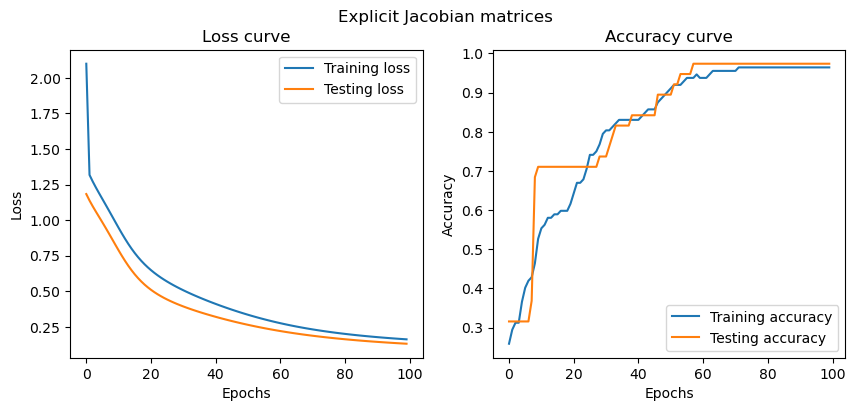

In [282]:
plot(
    explicit_train_losses,
    explicit_test_losses,
    explicit_train_accuracies,
    explicit_test_accuracies,
    "Explicit Jacobian matrices"
)

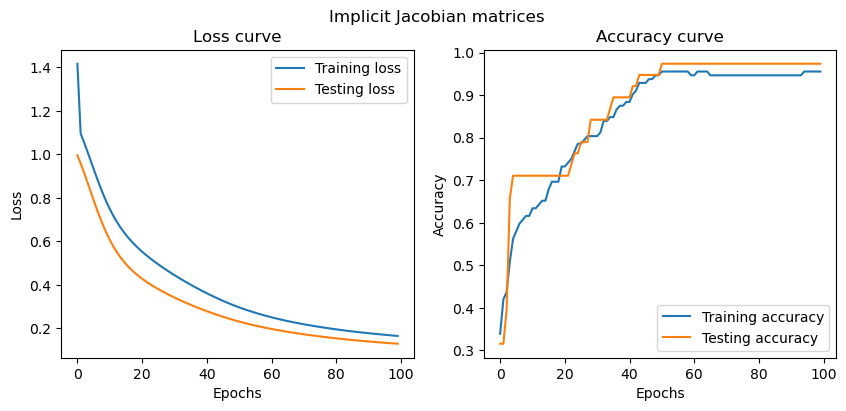

In [283]:
plot(
    implicit_train_losses,
    implicit_test_losses,
    implicit_train_accuracies,
    implicit_test_accuracies,
    "Implicit Jacobian matrices"
)

### Sources:
- https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf
- https://www.datacamp.com/tutorial/softmax-activation-function-in-python
- https://www.youtube.com/watch?v=RxbL5i8gczg